# Exploración Inicial de Datos

- Autores: Enmanuel Alejandro De Oleo y José Alexander De Sousa
- Repositorio de Github: https://github.com/alexdesousa7/ML-Practica-Only
- Última actualización: 29.05.2026

## 1. Explicación general de los datos existentes.

El maestro nos ha proveído de una tabla con las explicaciones necesarias sobre los datos con los que realizaremos este trabajo:

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |


## 2. Objetivo Principal de análisis:
  - 1. Poder predecir si una reserva será cancelada o no. (Utilizando el `is_cancel` con valores True/False o 1 o 0) como nuestra variable dependiente.
  - 2. Utilizando los siguientes modelos elegir el que obtenga mejores resultados de acuerdo a las métricas que se comentarán mas adelante:
    - Modelos:
      - Logistic Regression
      - Desicion Tree
      - Random Forest
      - XGBoost
      - Deep Neural Network

## 3. Configuración del Notebook

### Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")


### Definición de Constantes

In [2]:
PATH_DIRECTORIO_DATOS = "./../../data/raw"
PATH_DATASET = f"{PATH_DIRECTORIO_DATOS}/dataset_practica_final.csv"

# 4. Primeras observaciones de Dataset
### Mostrar las 5 primeras filas del mismo

In [3]:
df = pd.read_csv(PATH_DATASET)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Forma del Dataset e información general

In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


# Analisis de la variable objetivo

In [4]:
total = len(df)
canceled = df["is_canceled"].sum()
not_canceled = total - canceled

canceled_pct = (canceled / total) * 100
not_canceled_pct = (not_canceled / total) * 100

print(f"Canceladas:     {canceled} ({canceled_pct:.1f}%)")
print(f"No canceladas:  {not_canceled} ({not_canceled_pct:.1f}%)")
print(f"Total:          {total}")

Canceladas:     44224 (37.0%)
No canceladas:  75166 (63.0%)
Total:          119390


### Informacion grafica proporcionada por el dataset

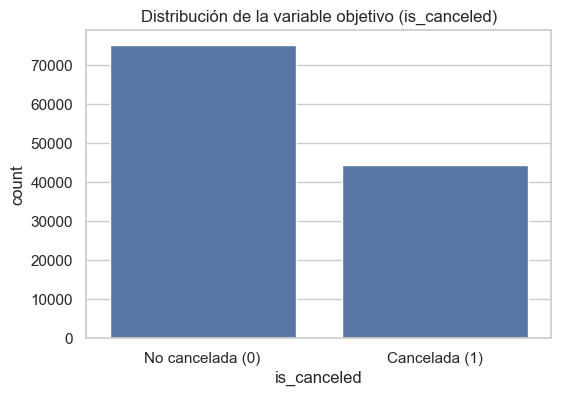

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="is_canceled")
plt.title("Distribución de la variable objetivo (is_canceled)")
plt.xticks([0, 1], ["No cancelada (0)", "Cancelada (1)"])
plt.savefig("../../outputs/distribucion_objetivo.png", dpi=300, bbox_inches="tight")

plt.show()

## Detección de valores nulos

In [9]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_ni

Las columnas que tienen nulos son: 
 - `agent`
 - `company`
 - `country`
 - `children`

Estas columnas pueden ser importantes para el análisis, por lo que es necesario decidir cómo manejar estos valores nulos (por ejemplo, imputación, eliminación, etc.) dependiendo del contexto y la cantidad de datos faltantes.

### Especial interés en la variable `company`

In [5]:
company_null_count = df["company"].isnull().sum()
print(f"Pct de valores nulos en company: {((company_null_count/total) * 100).round(2)}%")

Pct de valores nulos en company: 94.31%


Al ser un 94% de valores nulos muy seguramente terminemos eliminando esta variable, se definirá en la siguiente etapa de evaluación.

## Datos Interesantes
### Lead Time contra cancelaciones
 1. Esta grafica muestra que mientras más tiempo de anticipación (valor de lead_time) a la reserva, más probablemente cancelen. Mientras que los lead_time más pequeños tienen menor probabilidad de cancelación.
 2. Los lead times en cero, significan que se reservaron para el mismo dia, entonces tiene total sentido que no se cancelen.

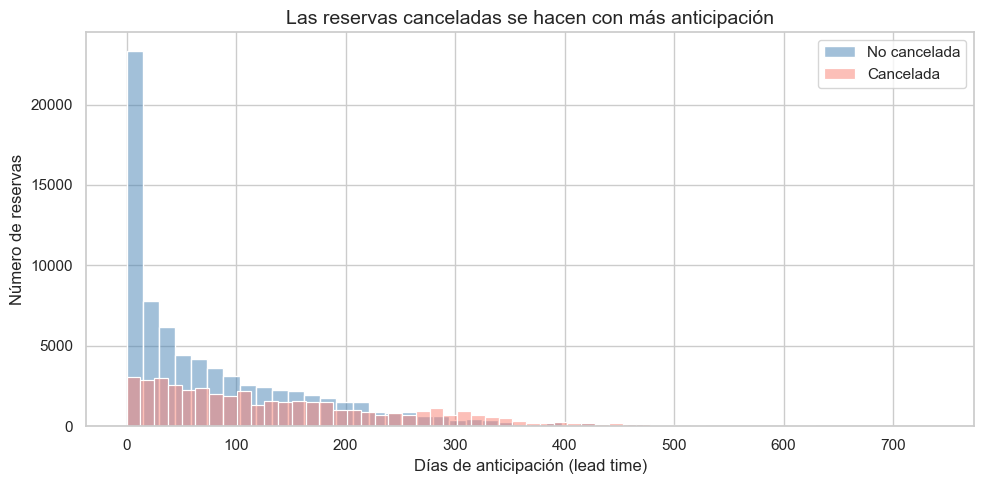

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
  df[df["is_canceled"] == 0]["lead_time"],
  label="No cancelada",
  color="steelblue",
  alpha=0.5,
  bins=50
)
sns.histplot(
  df[df["is_canceled"] == 1]["lead_time"],
  label="Cancelada",
  color="salmon",
  alpha=0.5,
  bins=50
)

plt.title("Las reservas canceladas se hacen con más anticipación", fontsize=14)
plt.xlabel("Días de anticipación (lead time)")
plt.ylabel("Número de reservas")
plt.legend()
plt.tight_layout()
plt.savefig("../../outputs/lead_time_vs_cancelacion.png", dpi=300, bbox_inches="tight")
plt.show()

### Lead time (distrubución)
1. Como podemos ver la gráfica está cargada en la izquierda y una cola larga hacia la derecha con valores muy muy bajos.
2. Con `log1p` podemos hacer la distribución un poco mas simetrica, no creo que se puede hacer "normal", pero esto ayuda.
3. Esto puede ayudar a los modelos `logisticRegression` y `Neural Network`.

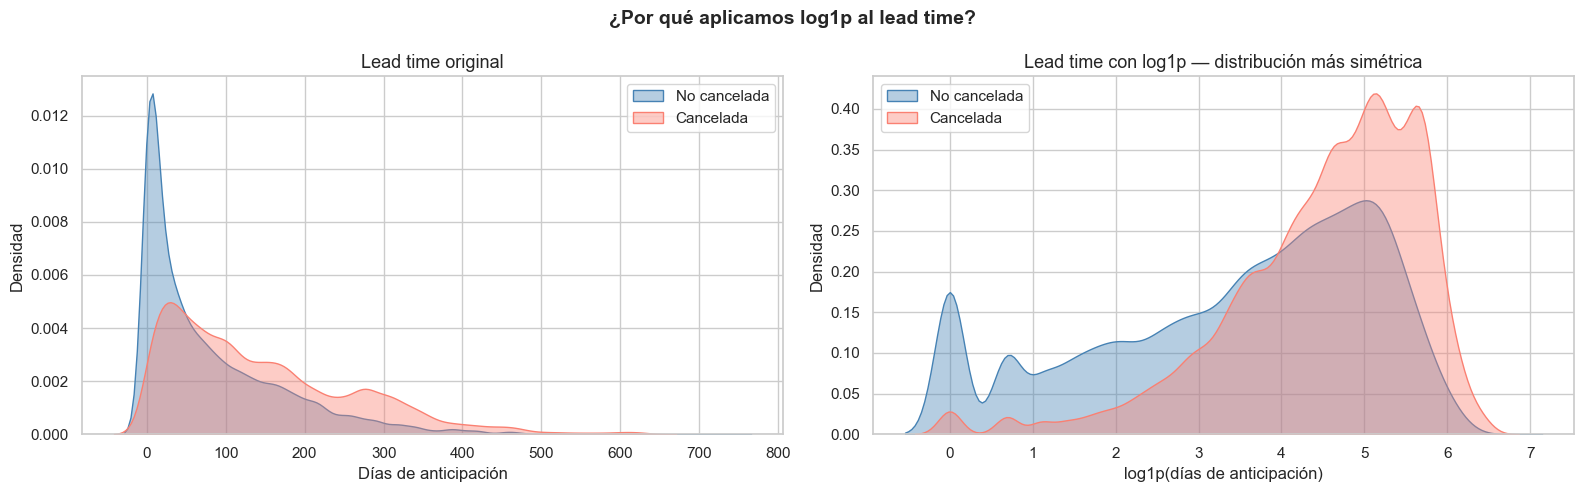

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].set_title("Lead time original", fontsize=13)
sns.kdeplot(df[df["is_canceled"] == 0]["lead_time"], label="No cancelada", color="steelblue", fill=True, alpha=0.4, ax=axes[0])
sns.kdeplot(df[df["is_canceled"] == 1]["lead_time"], label="Cancelada", color="salmon", fill=True, alpha=0.4, ax=axes[0])
axes[0].set_xlabel("Días de anticipación")
axes[0].set_ylabel("Densidad")
axes[0].legend()

df["lead_time_log"] = np.log1p(df["lead_time"])

axes[1].set_title("Lead time con log1p — distribución más simétrica", fontsize=13)
sns.kdeplot(df[df["is_canceled"] == 0]["lead_time_log"], label="No cancelada", color="steelblue", fill=True, alpha=0.4, ax=axes[1])
sns.kdeplot(df[df["is_canceled"] == 1]["lead_time_log"], label="Cancelada", color="salmon", fill=True, alpha=0.4, ax=axes[1])
axes[1].set_xlabel("log1p(días de anticipación)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.suptitle("¿Por qué aplicamos log1p al lead time?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/lead_time_log_comparacion.png", dpi=300, bbox_inches="tight")
plt.show()

### Cancelaciones por Meses
1. El mes con mayores tasa de cancelación es Junio.

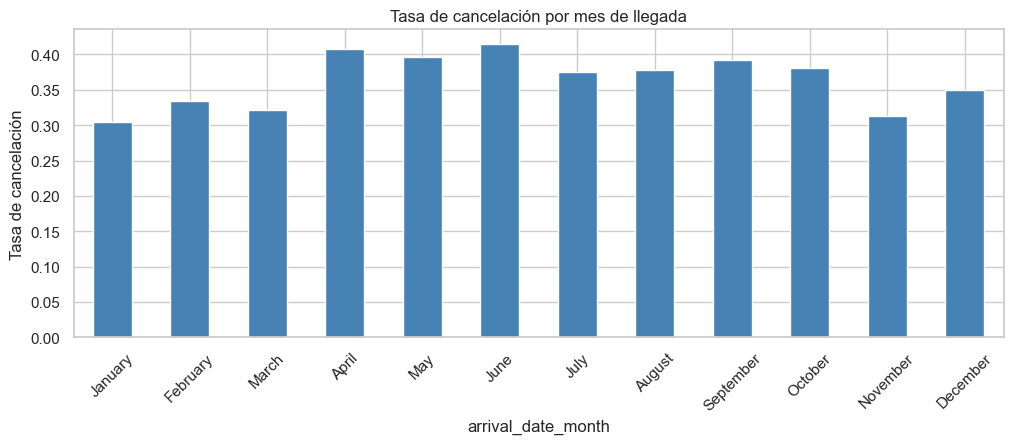

In [13]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly = df.groupby("arrival_date_month")["is_canceled"].mean().reindex(month_order)

plt.figure(figsize=(12, 4))
monthly.plot(kind="bar", color="steelblue")
plt.title("Tasa de cancelación por mes de llegada")
plt.ylabel("Tasa de cancelación")
plt.xticks(rotation=45)
plt.savefig("../../outputs/cancelacion_por_mes.png", dpi=300, bbox_inches="tight")
plt.show()

### Cambios de habiación vs pct de cancelaciones
1. Interesantemente cuando se cambian las habitaciones parece haber una menor posibilidad de cancelación... Esto es interesante... pero prodria ser (la verdad no lo tenemos claro) que sea porque en muchos casos esos cambios de habitación sea upgrades o sea una mejor habitación.

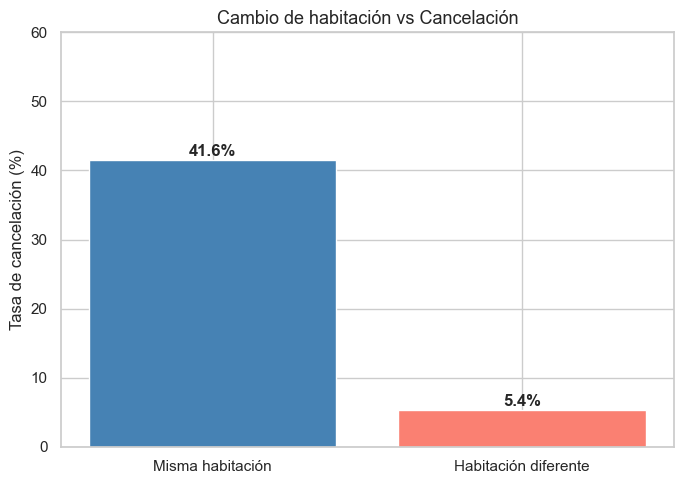

In [14]:
df["room_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

mismatch_rate = df.groupby("room_mismatch")["is_canceled"].mean() * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(
  ["Misma habitación", "Habitación diferente"],
  mismatch_rate.values,
  color=["steelblue", "salmon"]
)

for bar, val in zip(bars, mismatch_rate.values):
  plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.title("Cambio de habitación vs Cancelación", fontsize=13)
plt.ylabel("Tasa de cancelación (%)")
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig("../../outputs/room_mismatch.png", dpi=300, bbox_inches="tight")
plt.show()

### Cancelaciones por País
- PRT = Portugal
1. Portugal por mucho presenta la una tasa mayor cantidad de cancelaciones en comparación con otros paises. 

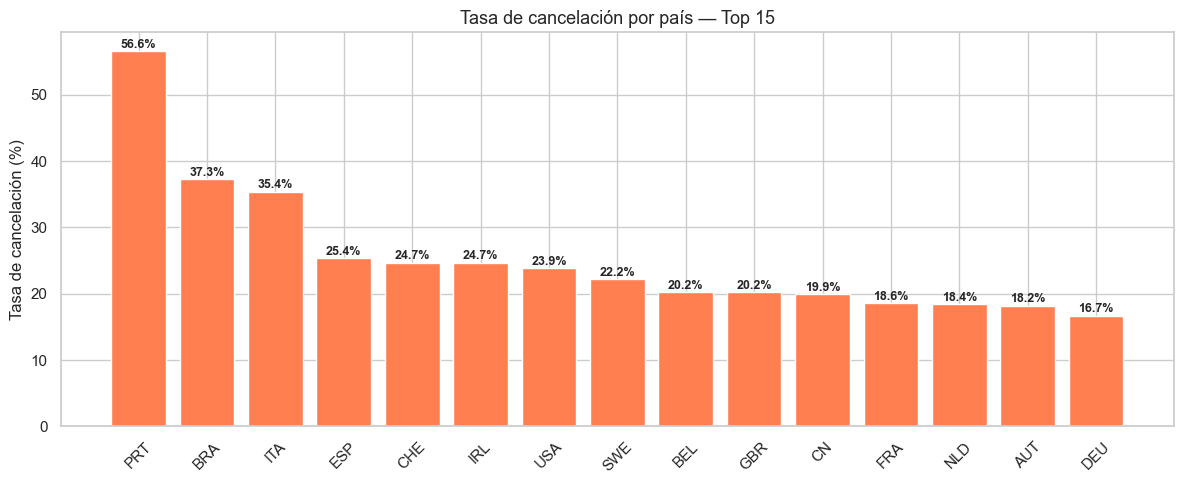

In [15]:
top_countries = df["country"].value_counts().head(15).index

country_cancel = (
    df[df["country"].isin(top_countries)]
    .groupby("country")["is_canceled"]
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
bars = plt.bar(country_cancel.index, country_cancel.values, color="coral")

for bar, val in zip(bars, country_cancel.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val}%", ha="center", fontsize=9, fontweight="bold")

plt.title("Tasa de cancelación por país — Top 15", fontsize=13)
plt.ylabel("Tasa de cancelación (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../outputs/cancelacion_por_pais.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
country_table = (
    df[df["country"].isin(top_countries)]
    .groupby("country")["is_canceled"]
    .agg(
        total="count",
        canceladas="sum",
    )
)

country_table["tasa_%"] = (country_table["canceladas"] / country_table["total"] * 100).round(1)
country_table = country_table.sort_values("tasa_%", ascending=False)

print(country_table.to_string())

         total  canceladas  tasa_%
country                           
PRT      48590       27519    56.6
BRA       2224         830    37.3
ITA       3766        1333    35.4
ESP       8568        2177    25.4
CHE       1730         428    24.7
IRL       3375         832    24.7
USA       2097         501    23.9
SWE       1024         227    22.2
BEL       2342         474    20.2
GBR      12129        2453    20.2
CN        1279         254    19.9
FRA      10415        1934    18.6
NLD       2104         387    18.4
AUT       1263         230    18.2
DEU       7287        1218    16.7


### Tipo de Deposito vs Cancelación

1. Es súper raro que un cliente que no pueda recuperar su dinero aún así cancela.
2. La gente que puede recuperar su dinero (aun que son minoria) en media son los que menos cancelan. (Es raro porque generalmente si puedes recuperar todo tu dinero pensariamos que seria mas fácil cancelar).

               total  canceladas  tasa_%
deposit_type                            
Non Refund     14587       14494    99.4
No Deposit    104641       29694    28.4
Refundable       162          36    22.2


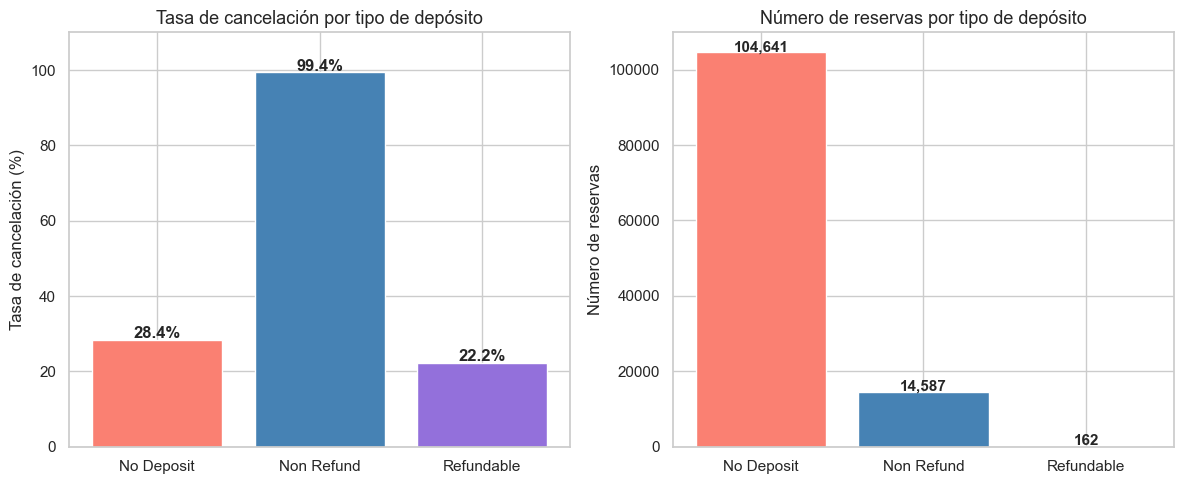

In [17]:
# Deposit Type vs Cancelación
deposit_rate = df.groupby("deposit_type")["is_canceled"].mean() * 100
deposit_count = df.groupby("deposit_type")["is_canceled"].count()

# Tabla
deposit_table = pd.DataFrame({
    "total": deposit_count,
    "canceladas": df.groupby("deposit_type")["is_canceled"].sum(),
    "tasa_%": deposit_rate.round(1)
}).sort_values("tasa_%", ascending=False)

print(deposit_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(
    deposit_rate.index,
    deposit_rate.values,
    color=["salmon", "steelblue", "mediumpurple"]
)
for bar, val in zip(bars, deposit_rate.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        f"{val:.1f}%",
        ha="center", fontsize=12, fontweight="bold"
    )
axes[0].set_title("Tasa de cancelación por tipo de depósito", fontsize=13)
axes[0].set_ylabel("Tasa de cancelación (%)")
axes[0].set_ylim(0, 110)

bars2 = axes[1].bar(
    deposit_count.index,
    deposit_count.values,
    color=["salmon", "steelblue", "mediumpurple"]
)
for bar, val in zip(bars2, deposit_count.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 200,
        f"{val:,}",
        ha="center", fontsize=11, fontweight="bold"
    )
axes[1].set_title("Número de reservas por tipo de depósito", fontsize=13)
axes[1].set_ylabel("Número de reservas")

plt.tight_layout()
plt.savefig("../../outputs/cancelacion_por_deposit_type.png", dpi=300, bbox_inches="tight")
plt.show()

### Variables Numéricas & Categóricas

In [18]:
engineered_cols = ["room_mismatch", "lead_time_log"]

numeric_cols = [
  col for col in df.select_dtypes(include=["int64", "float64"]).columns.tolist()
  if col not in engineered_cols
]
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

numeric_cols, categorical_cols

(['is_canceled',
  'lead_time',
  'arrival_date_year',
  'arrival_date_week_number',
  'arrival_date_day_of_month',
  'stays_in_weekend_nights',
  'stays_in_week_nights',
  'adults',
  'children',
  'babies',
  'is_repeated_guest',
  'previous_cancellations',
  'previous_bookings_not_canceled',
  'booking_changes',
  'agent',
  'company',
  'days_in_waiting_list',
  'adr',
  'required_car_parking_spaces',
  'total_of_special_requests'],
 ['hotel',
  'arrival_date_month',
  'meal',
  'country',
  'market_segment',
  'distribution_channel',
  'reserved_room_type',
  'assigned_room_type',
  'deposit_type',
  'customer_type',
  'reservation_status',
  'reservation_status_date'])

### Distribución de algunas variables numéricas y categóricas

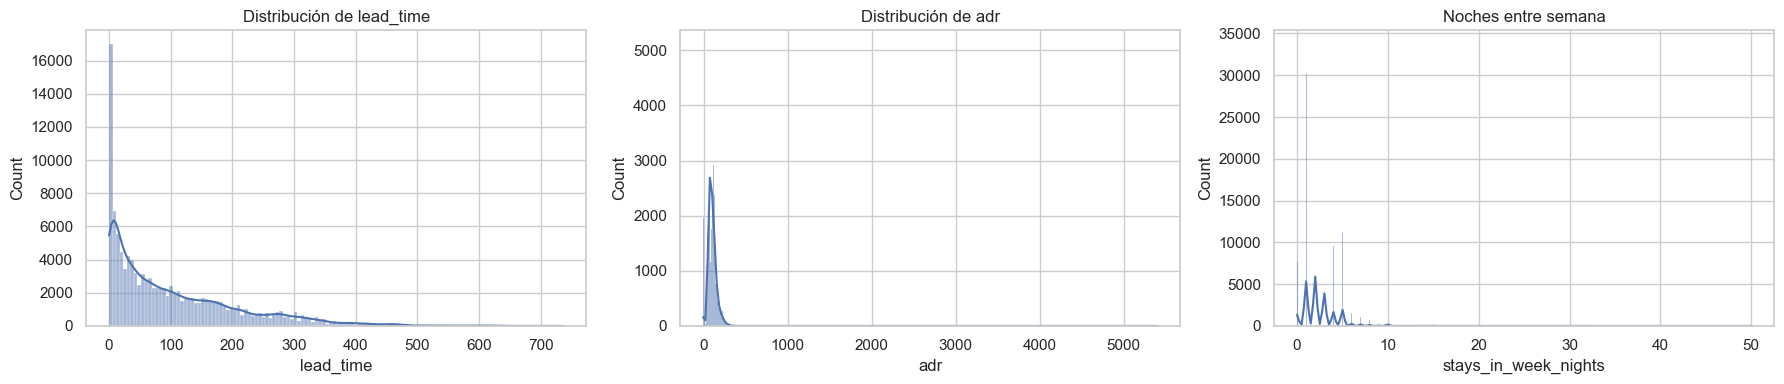

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["lead_time"], kde=True, ax=axes[0])
axes[0].set_title("Distribución de lead_time")

sns.histplot(df["adr"], kde=True, ax=axes[1])
axes[1].set_title("Distribución de adr")

sns.histplot(df["stays_in_week_nights"], kde=True, ax=axes[2])
axes[2].set_title("Noches entre semana")

plt.tight_layout()
plt.savefig("../../outputs/distribuciones_numericas.png", dpi=300, bbox_inches="tight")

plt.show()

### Variables que deberian tener valores positivos
- total_of_special_requests
- adr
- days_in_waiting_list
- booking_changes
- previous_bookings_not_canceled
- previous_cancellations
- stays_in_week_nights
- stays_in_weekend_nights
- lead_time

In [20]:
cols = [
  'total_of_special_requests',
  'adr',
  'days_in_waiting_list',
  'booking_changes',
  'previous_bookings_not_canceled',
  'previous_cancellations',
  'stays_in_week_nights',
  'stays_in_weekend_nights',
  'lead_time'
]

negative_summary = pd.DataFrame({
  "negativos": [df[df[col] < 0][col].count() for col in cols],
  "valor_min": [df[col].min() for col in cols],
}, index=cols)

print(negative_summary.to_string())


                                negativos  valor_min
total_of_special_requests               0       0.00
adr                                     1      -6.38
days_in_waiting_list                    0       0.00
booking_changes                         0       0.00
previous_bookings_not_canceled          0       0.00
previous_cancellations                  0       0.00
stays_in_week_nights                    0       0.00
stays_in_weekend_nights                 0       0.00
lead_time                               0       0.00


### Relacion de algunas variables con el target
ejemplo: hotel, market_segment, customer_type vs is_canceled

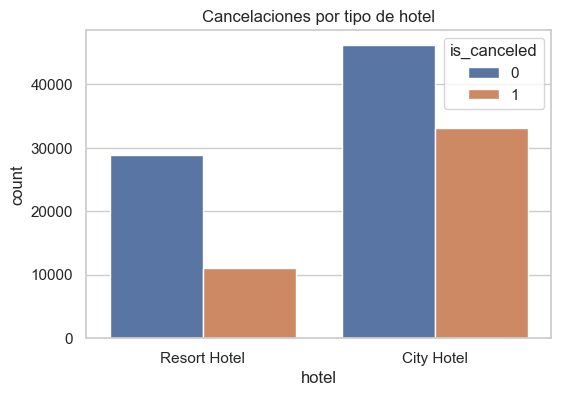

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="hotel", hue="is_canceled")
plt.title("Cancelaciones por tipo de hotel")
plt.savefig("../../outputs/cancelaciones_por_tipo_hotel.png", dpi=300, bbox_inches="tight")

plt.show()

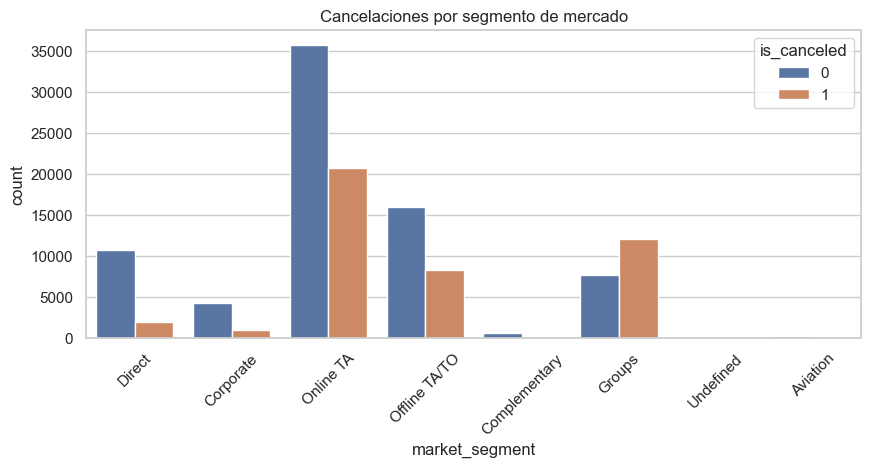

In [22]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="market_segment", hue="is_canceled")
plt.title("Cancelaciones por segmento de mercado")
plt.xticks(rotation=45)
plt.savefig("../../outputs/cancelaciones_por_segmento.png", dpi=300, bbox_inches="tight")

plt.show()



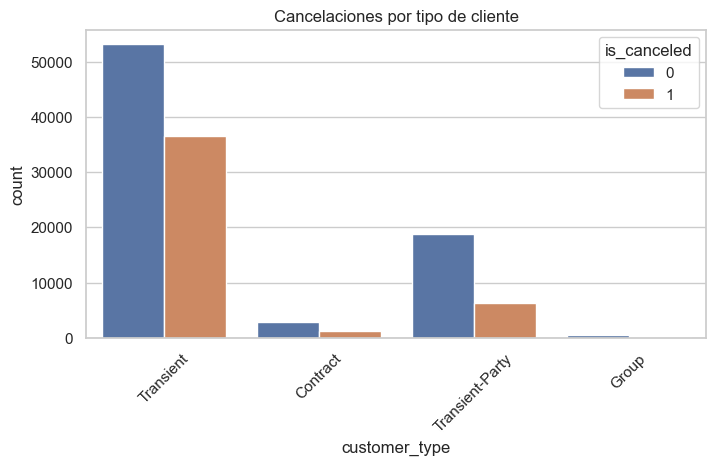

In [23]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="customer_type", hue="is_canceled")
plt.title("Cancelaciones por tipo de cliente")
plt.xticks(rotation=45)
plt.savefig("../../outputs/cancelaciones_por_tipo_cliente.png", dpi=300, bbox_inches="tight")

plt.show()

### Correlacion entre variables numericas

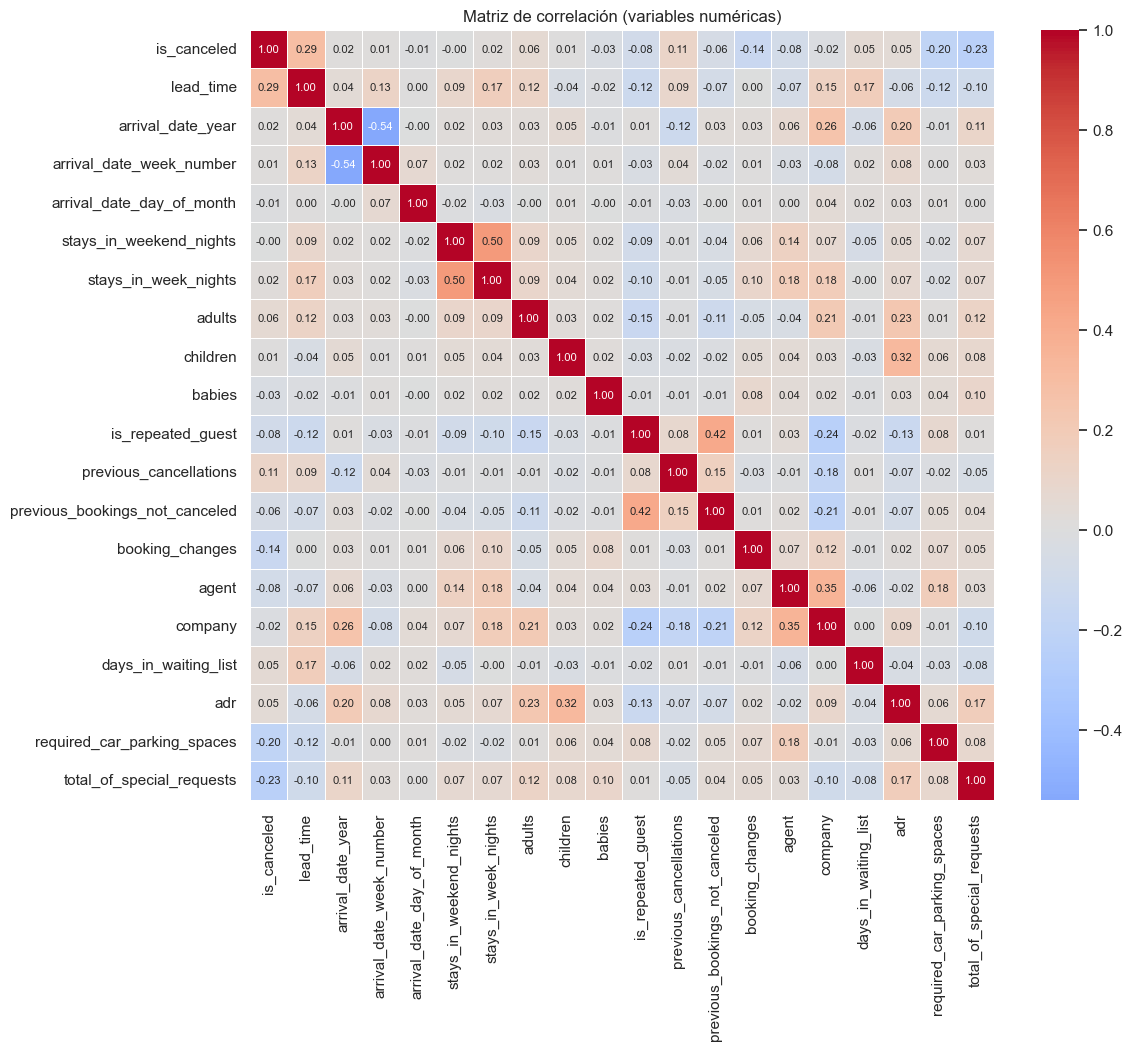

In [24]:
plt.figure(figsize=(12, 10))
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,          # Muestra los valores numéricos
    fmt=".2f",           # Formato de los números (2 decimales)
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Matriz de correlación (variables numéricas)")
plt.savefig("../../outputs/matriz_correlacion.png", dpi=300, bbox_inches="tight")

plt.show()

Para facilitar la interpretación, se pueden destacar las correlaciones más fuertes (por ejemplo, > 0.5 o < -0.5) con un color diferente o anotarlas de alguna manera. Esto ayuda a identificar rápidamente qué variables numéricas están más relacionadas entre sí y con la variable objetivo "is_canceled".

## Decisión sobre variables que podrían ser eliminadas o modificadas para el procesamiento
| Decisión | Justificación |
|---|---|
| Eliminar `company` | 94.31% de valores nulos — no aporta valor |
| Eliminar `reservation_status` y `reservation_status_date` | Data que podía dañar o sesgar nuestra predicción — son consecuencia directa de la cancelación |
| Crear `room_mismatch` | Hallazgo del EDA — habitación diferente reduce cancelaciones |
| Aplicar `log1p` a `lead_time` | Distribución con sesgo a la derecha para mejorar la 'normalización' de la distribución |
| Crear `has_agent` en lugar de usar el ID | El ID del agente no tiene valor numérico real podria ser mejor tener un valor True/False  |
| Corregir negativos en columnas como `adr` | El `describe()` mostró valores negativos imposibles y en variables que deben ser positivas |

# Conclusiones del EDA inicial:

## Hallazgos interesantes
**1. Canceladas vs no canceladas**
El 37% de las reservas fueron canceladas y el 63% no. No es un desbalance extremo, 
pero es suficiente para que métricas como accuracy sean engañosas. 
Usaremos ROC-AUC, F1-score y recall como métricas principales.

**2. Lead time parece ser predictor significativo**
Las reservas canceladas se hicieron en promedio con más días de anticipación que las 
no canceladas. Cuanto más tiempo pasa entre la reserva y la llegada, más probable es 
que los planes cambien.

**3. Deposit type es raro (contraintuitivo)**
Las reservas con depósito "Non Refund" tienen una tasa de cancelación cercana al 99%. 
Aunque el cliente ya pagó y no puede recuperar el dinero, cancela igualmente.

**4. Room mismatch reduce las cancelaciones**
Cuando el hotel asigna una habitación diferente a la reservada, la tasa de cancelación 
baja drásticamente. La hipótesis más probable es que estos cambios sean upgrades, 
lo que genera satisfacción en el cliente.

**5. Portugal concentra el mayor volumen y tasa de cancelaciones**
PRT tiene una tasa del 56.6% de cancelación, muy por encima del resto de países. 